In [1]:
#Importing libraries

import numpy as np
import matplotlib.pyplot as plt

In [2]:
N_JOBS = 100
N_MACHINES = 4

In [3]:
#creating the input data for the student ID
import random

def generateData(seed=0):
    PROC = [ [ 0 for m in range(N_MACHINES) ] for j in range(N_JOBS) ]
    random.seed(seed)
    for j in range(N_JOBS):
        for m in range(N_MACHINES):
            PROC[j][m] = random.randint(1,9)
    return PROC

In [4]:
proc_times = generateData(8801)
proc_times

[[4, 4, 5, 4],
 [8, 1, 8, 8],
 [5, 9, 2, 7],
 [7, 3, 6, 8],
 [2, 2, 9, 8],
 [4, 6, 2, 9],
 [3, 5, 2, 9],
 [3, 7, 9, 7],
 [7, 1, 3, 1],
 [7, 6, 9, 7],
 [3, 3, 2, 3],
 [2, 7, 7, 1],
 [5, 8, 4, 5],
 [7, 3, 4, 7],
 [8, 9, 3, 4],
 [3, 7, 8, 1],
 [6, 3, 2, 4],
 [9, 5, 6, 4],
 [6, 4, 4, 1],
 [4, 6, 2, 4],
 [9, 6, 9, 7],
 [3, 1, 6, 9],
 [6, 5, 2, 5],
 [4, 4, 7, 6],
 [3, 2, 7, 3],
 [2, 1, 5, 7],
 [3, 3, 2, 4],
 [5, 6, 5, 9],
 [6, 8, 2, 1],
 [6, 8, 6, 5],
 [9, 2, 5, 6],
 [9, 3, 4, 6],
 [1, 6, 2, 8],
 [7, 5, 5, 2],
 [1, 2, 5, 3],
 [3, 9, 9, 4],
 [2, 4, 6, 9],
 [2, 8, 9, 5],
 [9, 6, 2, 6],
 [7, 7, 6, 5],
 [5, 9, 5, 7],
 [4, 7, 2, 5],
 [7, 3, 6, 5],
 [4, 5, 1, 2],
 [2, 1, 7, 8],
 [1, 7, 4, 4],
 [8, 4, 1, 8],
 [6, 8, 4, 2],
 [4, 6, 7, 5],
 [2, 7, 9, 7],
 [6, 1, 3, 3],
 [5, 5, 1, 8],
 [9, 9, 6, 2],
 [3, 8, 7, 5],
 [3, 8, 2, 4],
 [6, 1, 2, 7],
 [5, 3, 6, 1],
 [9, 4, 1, 5],
 [8, 9, 2, 7],
 [7, 7, 5, 2],
 [2, 1, 6, 1],
 [9, 5, 2, 7],
 [9, 1, 3, 9],
 [7, 1, 7, 3],
 [1, 2, 4, 8],
 [9, 5, 4, 2],
 [7, 4, 2,

In [5]:
#basic greedy job sequence

def greedy_job_sequence(proc_times):
    n_jobs, n_machines = len(proc_times), len(proc_times[0])
    job_sequence = []
    machine_end_times = [0] * n_machines
    
    sorted_jobs = sorted(range(n_jobs), key=lambda x: min(proc_times[x]))
    
    for job_index in sorted_jobs:
        best_machine = None
        min_completion_time = float('inf')
        
        for machine_index in range(n_machines):
            completion_time = max(machine_end_times[machine_index], proc_times[job_index][machine_index]) + proc_times[job_index][machine_index]
            if completion_time < min_completion_time:
                min_completion_time = completion_time
                best_machine = machine_index
        
        job_sequence.append(job_index)
        machine_end_times[best_machine] = min_completion_time
    
    return job_sequence


In [6]:
#iterated greedy job sequence

import time

def evaluate_completion_times(job_sequence, proc_times):
    n_jobs, n_machines = len(job_sequence), len(proc_times[0])
    machine_end_times = [0] * n_machines
    completion_times = [0] * n_jobs

    for job_index in job_sequence:
        for machine_index in range(n_machines):
            machine_end_times[machine_index] = max(machine_end_times[machine_index], completion_times[job_index])
            completion_times[job_index] = machine_end_times[machine_index] + proc_times[job_index][machine_index]

    return completion_times

def local_search(job_sequence, proc_times):
    n_jobs = len(job_sequence)
    best_sequence = list(job_sequence)
    best_completion_times = evaluate_completion_times(best_sequence, proc_times)

    improved = True
    while improved:
        improved = False
        for i in range(n_jobs):
            for j in range(i + 1, n_jobs):
                new_sequence = list(job_sequence)
                new_sequence[i], new_sequence[j] = new_sequence[j], new_sequence[i]
                new_completion_times = evaluate_completion_times(new_sequence, proc_times)

                if max(new_completion_times) < max(best_completion_times):
                    best_sequence = list(new_sequence)
                    best_completion_times = list(new_completion_times)
                    improved = True

        job_sequence = list(best_sequence)

    return job_sequence

def iterated_greedy_job_sequence(proc_times, max_iterations):
    n_jobs = len(proc_times)
    best_job_sequence = None
    best_completion_time = float('inf')

    start_time = time.time()  # Record start time

    for _ in range(max_iterations):
        initial_sequence = greedy_job_sequence(proc_times)
        improved_sequence = local_search(initial_sequence, proc_times)
        completion_times = evaluate_completion_times(improved_sequence, proc_times)
        
        max_completion_time = max(completion_times)

        if max_completion_time < best_completion_time:
            best_job_sequence = improved_sequence
            best_completion_time = max_completion_time

    end_time = time.time()  # Record end time
    elapsed_time = end_time - start_time  # Calculate elapsed time

    return best_job_sequence, elapsed_time



In [7]:
#output sequence for Greedy approach
best_sequence = greedy_job_sequence(proc_times)
best_sequence

[1,
 8,
 11,
 15,
 18,
 21,
 25,
 28,
 32,
 34,
 43,
 44,
 45,
 46,
 50,
 51,
 55,
 56,
 57,
 60,
 62,
 63,
 64,
 71,
 77,
 87,
 89,
 90,
 92,
 95,
 96,
 97,
 99,
 2,
 4,
 5,
 6,
 10,
 16,
 19,
 22,
 24,
 26,
 30,
 33,
 36,
 37,
 38,
 41,
 47,
 49,
 52,
 54,
 58,
 59,
 61,
 65,
 66,
 67,
 68,
 70,
 73,
 74,
 75,
 76,
 78,
 81,
 84,
 85,
 86,
 88,
 91,
 93,
 98,
 3,
 7,
 13,
 14,
 31,
 35,
 42,
 53,
 72,
 82,
 83,
 94,
 0,
 12,
 17,
 23,
 48,
 69,
 79,
 80,
 27,
 29,
 39,
 40,
 9,
 20]

In [8]:
#output sequence for Iterated Greedy approach

max_iterations = 200
best_sequence_iterated, elapsed_time = iterated_greedy_job_sequence(proc_times, max_iterations)
print("Best Job Sequence:", best_sequence_iterated)
print("Elapsed Time:", elapsed_time, "seconds")


Best Job Sequence: [1, 8, 11, 15, 18, 21, 25, 28, 32, 34, 43, 44, 45, 46, 50, 51, 55, 56, 57, 60, 62, 63, 64, 71, 77, 87, 89, 90, 92, 95, 96, 97, 99, 2, 4, 5, 6, 10, 16, 19, 22, 24, 26, 30, 33, 36, 37, 38, 41, 47, 49, 52, 54, 58, 59, 61, 65, 66, 67, 68, 70, 73, 74, 75, 76, 78, 81, 84, 85, 86, 88, 91, 93, 98, 3, 7, 13, 14, 31, 35, 42, 53, 72, 82, 83, 94, 0, 12, 17, 23, 48, 69, 79, 80, 27, 29, 39, 40, 9, 20]
Elapsed Time: 152.89881825447083 seconds


In [9]:
#plot Gantt chart
import matplotlib.pyplot as plt
import numpy as np

def plot_gantt_chart(proc_times, sequence):
    proc_times = np.array(proc_times) 

    n_jobs, n_machines = proc_times.shape
    machine_end_times = [0] * n_machines
    job_colors = plt.cm.tab20(np.linspace(0, 1, n_jobs))  # Using tab20 color map for 20 distinct colors

    fig, ax = plt.subplots(figsize=(30, 10)) 
    for job_index in sequence:
        for machine_index in range(n_machines):
            start_time = max(machine_end_times[machine_index], machine_end_times[machine_index - 1]) if machine_index > 0 else machine_end_times[0]
            end_time = start_time + proc_times[job_index][machine_index]
            bar_width = proc_times[job_index][machine_index]
            ax.barh(machine_index, bar_width, left=start_time, color=job_colors[job_index], edgecolor='black')
            ax.text(start_time + bar_width / 2, machine_index, 'Job {}'.format(job_index), ha='center', va='center', color='white')
            machine_end_times[machine_index] = end_time

    ax.set_xlabel('Time')
    ax.set_ylabel('Machine')
    ax.set_title('Job Shop Scheduling Gantt Chart')
    ax.set_yticks(range(n_machines))
    ax.set_yticklabels(['Machine {}'.format(i) for i in range(1, n_machines + 1)])
    ax.set_xticks(np.arange(0, max(machine_end_times) + 1, 1))  

    ax.grid(which='both', axis='x', linestyle='--', alpha=0.6) 
    ax.invert_yaxis()
    plt.tight_layout()  
    plt.show() 


Best sequence: [1, 8, 11, 15, 18, 21, 25, 28, 32, 34, 43, 44, 45, 46, 50, 51, 55, 56, 57, 60, 62, 63, 64, 71, 77, 87, 89, 90, 92, 95, 96, 97, 99, 2, 4, 5, 6, 10, 16, 19, 22, 24, 26, 30, 33, 36, 37, 38, 41, 47, 49, 52, 54, 58, 59, 61, 65, 66, 67, 68, 70, 73, 74, 75, 76, 78, 81, 84, 85, 86, 88, 91, 93, 98, 3, 7, 13, 14, 31, 35, 42, 53, 72, 82, 83, 94, 0, 12, 17, 23, 48, 69, 79, 80, 27, 29, 39, 40, 9, 20]


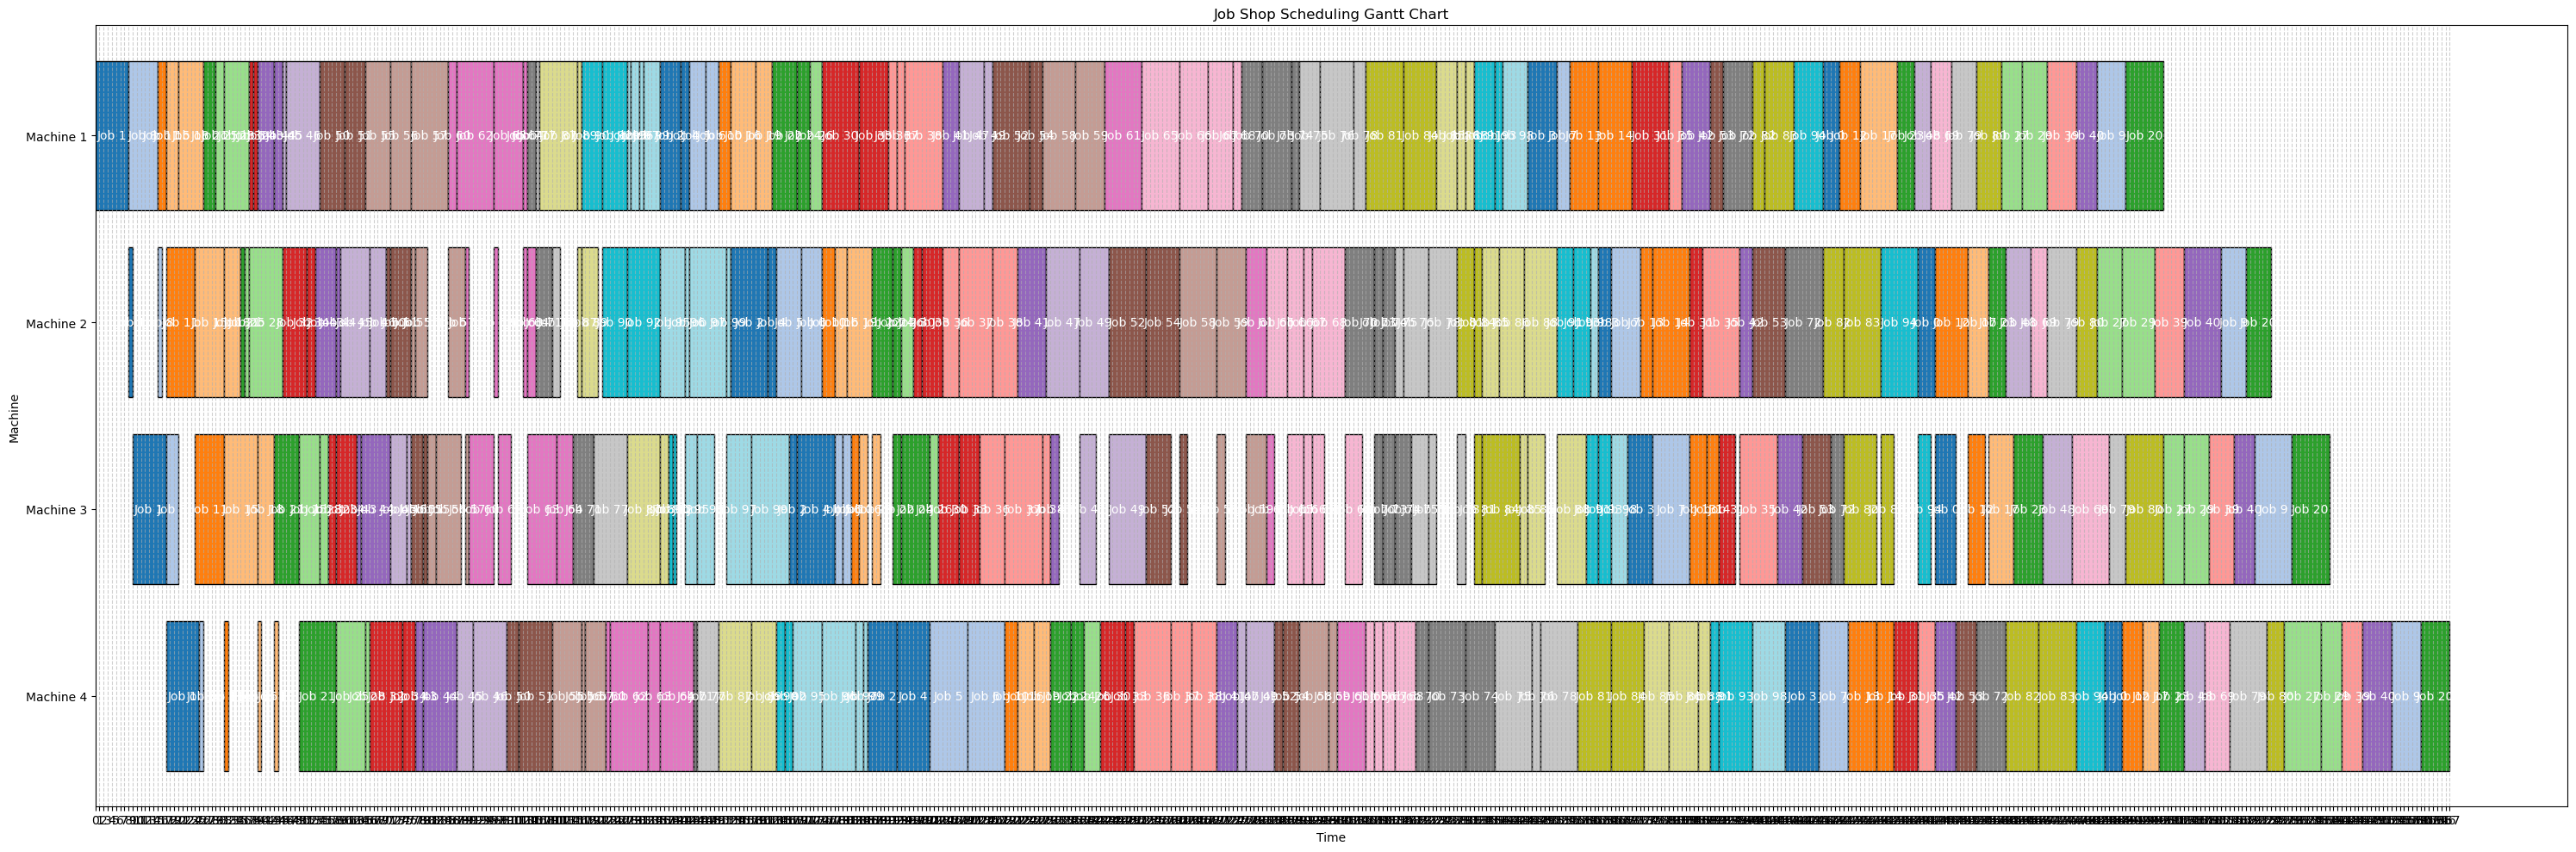

In [10]:
#Gantt chart for Greedy Approach
print("Best sequence:", best_sequence)
plot_gantt_chart(proc_times, best_sequence)


Best sequence Iterated: [1, 8, 11, 15, 18, 21, 25, 28, 32, 34, 43, 44, 45, 46, 50, 51, 55, 56, 57, 60, 62, 63, 64, 71, 77, 87, 89, 90, 92, 95, 96, 97, 99, 2, 4, 5, 6, 10, 16, 19, 22, 24, 26, 30, 33, 36, 37, 38, 41, 47, 49, 52, 54, 58, 59, 61, 65, 66, 67, 68, 70, 73, 74, 75, 76, 78, 81, 84, 85, 86, 88, 91, 93, 98, 3, 7, 13, 14, 31, 35, 42, 53, 72, 82, 83, 94, 0, 12, 17, 23, 48, 69, 79, 80, 27, 29, 39, 40, 9, 20]


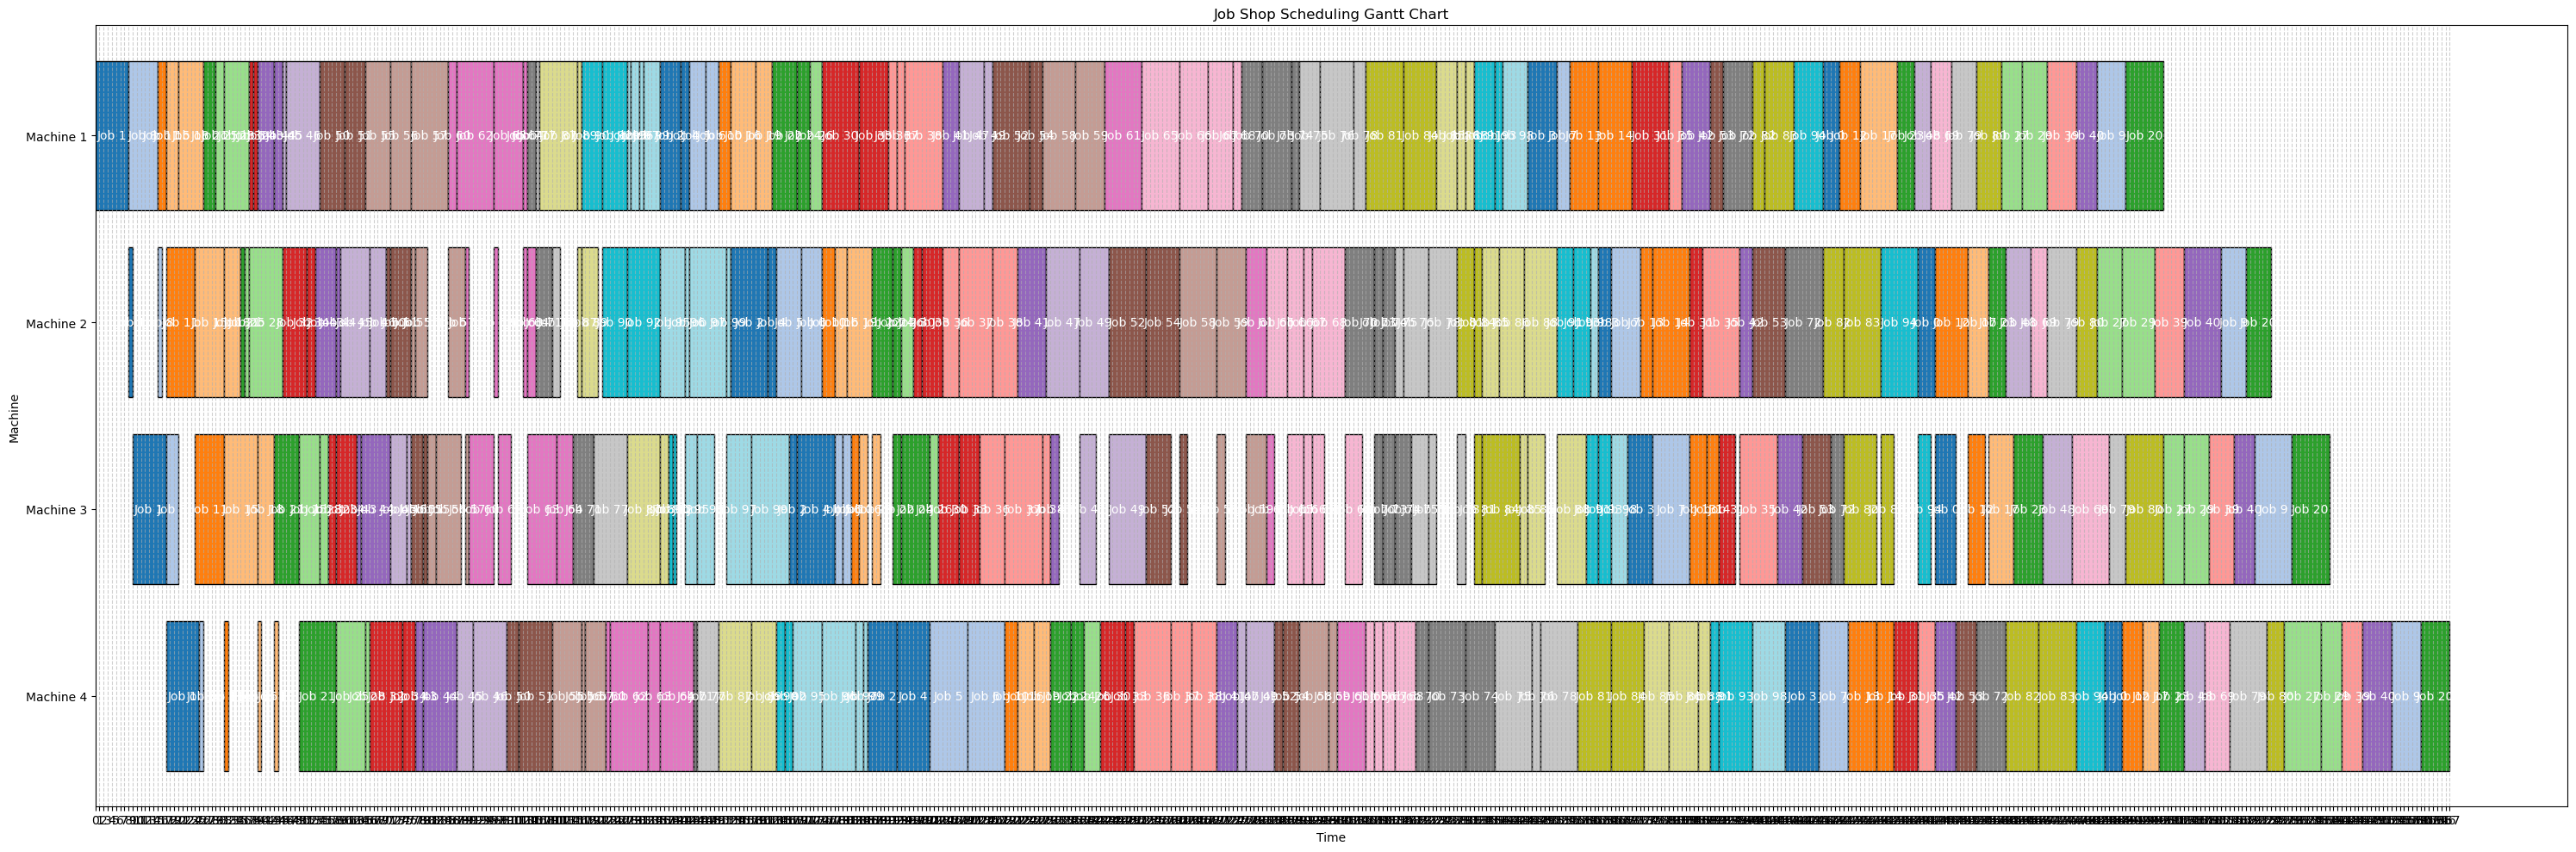

In [11]:
#Gantt chart for Iterated Greedy Approach

print("Best sequence Iterated:", best_sequence_iterated)
plot_gantt_chart(proc_times, best_sequence_iterated)


In [12]:
def calculate_idle_and_total_time(proc_times, sequence):
    n_jobs, n_machines = proc_times.shape
    machine_end_times = [0] * n_machines
    total_time = 0
    idle_times = [0] * n_machines

    for job_index in sequence:
        for machine_index in range(n_machines):
            start_time = max(machine_end_times[machine_index], machine_end_times[machine_index - 1]) if machine_index > 0 else machine_end_times[0]
            end_time = start_time + proc_times[job_index][machine_index]
            total_time = max(total_time, end_time)
            idle_time = max(0, start_time - machine_end_times[machine_index])
            idle_times[machine_index] += idle_time
            machine_end_times[machine_index] = end_time

    return idle_times, total_time


In [13]:
import numpy as np

proc_times = np.array(proc_times)  

idle_times, total_time = calculate_idle_and_total_time(proc_times, best_sequence)
print("Sequence", best_sequence)
print("Idle times for each machine:")
for idx, idle_time in enumerate(idle_times):
    print(f"Machine {idx + 1}: {idle_time} units")
print(f"Total time : {total_time} units")


Sequence [1, 8, 11, 15, 18, 21, 25, 28, 32, 34, 43, 44, 45, 46, 50, 51, 55, 56, 57, 60, 62, 63, 64, 71, 77, 87, 89, 90, 92, 95, 96, 97, 99, 2, 4, 5, 6, 10, 16, 19, 22, 24, 26, 30, 33, 36, 37, 38, 41, 47, 49, 52, 54, 58, 59, 61, 65, 66, 67, 68, 70, 73, 74, 75, 76, 78, 81, 84, 85, 86, 88, 91, 93, 98, 3, 7, 13, 14, 31, 35, 42, 53, 72, 82, 83, 94, 0, 12, 17, 23, 48, 69, 79, 80, 27, 29, 39, 40, 9, 20]
Idle times for each machine:
Machine 1: 0 units
Machine 2: 37 units
Machine 3: 84 units
Machine 4: 37 units
Total time : 567 units


In [14]:
import numpy as np

proc_times = np.array(proc_times)  

idle_times, total_time = calculate_idle_and_total_time(proc_times, best_sequence_iterated)
print("Sequence", best_sequence_iterated)

print("Idle times for each machine:")
for idx, idle_time in enumerate(idle_times):
    print(f"Machine {idx + 1}: {idle_time} units")
print(f"Total time : {total_time} units")


Sequence [1, 8, 11, 15, 18, 21, 25, 28, 32, 34, 43, 44, 45, 46, 50, 51, 55, 56, 57, 60, 62, 63, 64, 71, 77, 87, 89, 90, 92, 95, 96, 97, 99, 2, 4, 5, 6, 10, 16, 19, 22, 24, 26, 30, 33, 36, 37, 38, 41, 47, 49, 52, 54, 58, 59, 61, 65, 66, 67, 68, 70, 73, 74, 75, 76, 78, 81, 84, 85, 86, 88, 91, 93, 98, 3, 7, 13, 14, 31, 35, 42, 53, 72, 82, 83, 94, 0, 12, 17, 23, 48, 69, 79, 80, 27, 29, 39, 40, 9, 20]
Idle times for each machine:
Machine 1: 0 units
Machine 2: 37 units
Machine 3: 84 units
Machine 4: 37 units
Total time : 567 units
